<a href="https://colab.research.google.com/github/Muqqadas30/CodeAlpha_ML_Internship_Tasks/blob/main/task2/task2_emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa soundfile -q
!wget -q https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
!unzip -q Audio_Speech_Actors_01-24.zip -d RAVDESS

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

In [3]:
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

data_path = 'RAVDESS'
file_paths = []
emotions = []

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            parts = file.split('-')
            emotion_code = parts[2]
            file_paths.append(os.path.join(root, file))
            emotions.append(emotion_map[emotion_code])

df = pd.DataFrame({'path': file_paths, 'emotion': emotions})
print(df.shape)
df['emotion'].value_counts()

(1440, 2)


,count
emotion,
calm,192
disgust,192
happy,192
sad,192
angry,192
surprised,192
fearful,192
neutral,96


In [4]:
def extract_features(file_path, max_pad_len=174):
    audio, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    pad_width = max_pad_len - mfcc.shape[1]
    if pad_width > 0:
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc

features = []
for path in df['path']:
    features.append(extract_features(path))

X = np.array(features)
print(X.shape)

(1440, 40, 174)


In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['emotion'])
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

print(X_train.shape, X_test.shape)

(1152, 40, 174) (288, 40, 174)


In [6]:
model = Sequential([
    Conv1D(128, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(256, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(y_cat.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 36, 128)        │       111,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 36, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 14, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,512 (2.04 MB)

 Trainable params: 532,488 (2.03 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.1615 - loss: 2.5995 - val_accuracy: 0.1424 - val_loss: 2.0559
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.2161 - loss: 2.2876 - val_accuracy: 0.1354 - val_loss: 2.0450
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2517 - loss: 2.1164 - val_accuracy: 0.2292 - val_loss: 1.9511
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.2995 - loss: 2.0036 - val_accuracy: 0.3368 - val_loss: 1.8752
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3255 - loss: 1.8438 - val_accuracy: 0.3368 - val_loss: 1.8032
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3377 - loss: 1.8157 - val_accuracy: 0.4271 - val_loss: 1.6919
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3819 - loss: 1.6950 - val_accuracy: 0.4514 - val_loss: 1.6188
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4010 - loss: 1.6363 - val_accuracy: 0.4514 - v

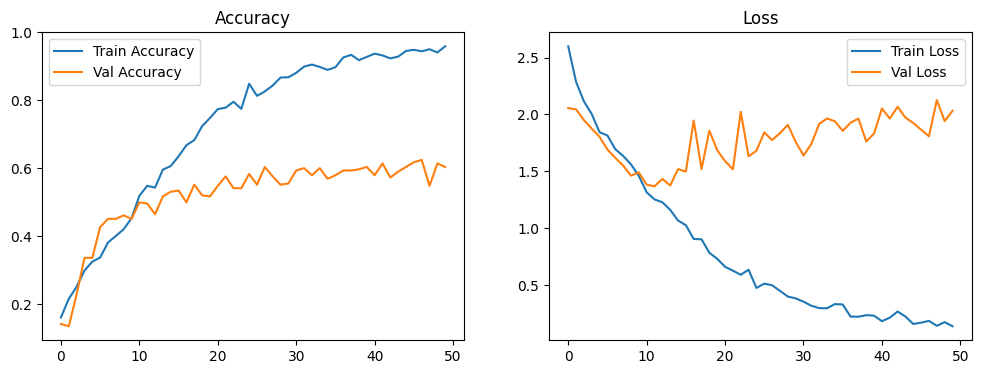

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6042 - loss: 2.0327
0.6041666865348816
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


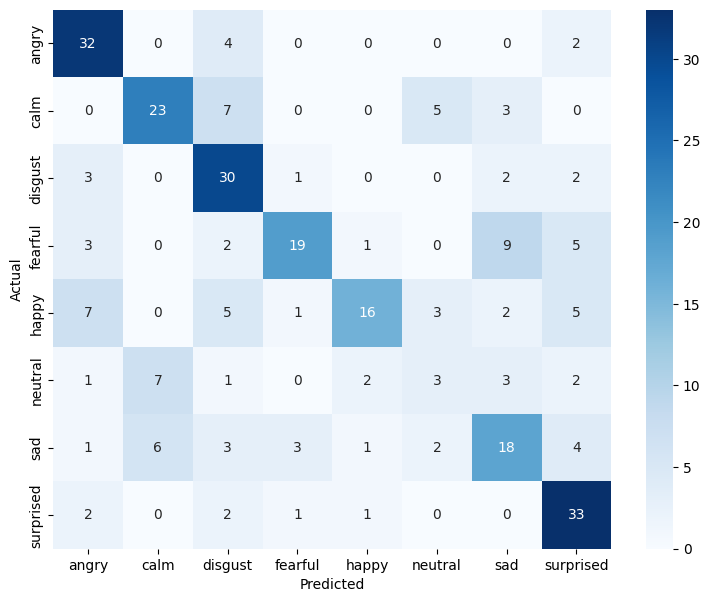

              precision    recall  f1-score   support

       angry       0.65      0.84      0.74        38
        calm       0.64      0.61      0.62        38
     disgust       0.56      0.79      0.65        38
     fearful       0.76      0.49      0.59        39
       happy       0.76      0.41      0.53        39
     neutral       0.23      0.16      0.19        19
         sad       0.49      0.47      0.48        38
   surprised       0.62      0.85      0.72        39

    accuracy                           0.60       288
   macro avg       0.59      0.58      0.57       288
weighted avg       0.61      0.60      0.59       288



In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(test_acc)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_true, y_pred, target_names=le.classes_))

In [10]:
model.save('emotion_recognition_model.h5')